# Clustering Crédit - Partie 0: Rappel du Cours

🎯 **Objectif**: Réviser les concepts clés du clustering avant l'application pratique

📋 **Programme**:
1. Qu'est-ce que le clustering ? (définition, objectifs)
2. Les 3 familles d'algorithmes principales
3. Métriques d'évaluation
4. Bonnes pratiques et pièges à éviter
5. Quiz interactif de validation

💡 **Avant de commencer**: Ce rappel vous prépare aux Parties 1-3 de l'exercice pratique.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from ipywidgets import interact, IntSlider, Dropdown, interactive
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("📚 Environnement prêt pour le rappel de cours!")

📚 Environnement prêt pour le rappel de cours!


## 1️⃣ Qu'est-ce que le Clustering ?

Le clustering (ou partitionnement) est une technique d'**apprentissage non supervisé** qui consiste à regrouper des observations similaires sans connaître les groupes à l'avance.

### Objectifs principaux:
- 🔍 **Exploration**: Découvrir des structures cachées dans les données
- 🎯 **Segmentation**: Diviser une population en groupes homogènes  
- 📊 **Réduction de complexité**: Simplifier l'analyse d'un grand dataset
- 💼 **Applications métier**: Marketing, biologie, recommandations, etc.

### Différence avec la classification supervisée:
- **Clustering**: Pas d'étiquettes → on découvre les groupes
- **Classification**: Étiquettes connues → on prédit la classe

In [ ]:
# Démonstration interactive: clustering vs classification
@interact(
    dataset=Dropdown(options=['Blobs séparés', 'Cercles concentriques', 'Données aléatoires'], 
                    value='Blobs séparés', description='Type de données:'),
    afficher=Dropdown(options=['Données brutes', 'Clustering K-Means', 'Vraies classes'], 
                     value='Données brutes', description='Vue:')
)
def demo_clustering_vs_classification(dataset, afficher):
    """Démonstration interactive clustering vs classification"""
    
    # Génération des données
    if dataset == 'Blobs séparés':
        X, y_true = make_blobs(n_samples=300, centers=4, n_features=2, 
                              cluster_std=1.0, random_state=42)
        titre_base = "Données avec 4 groupes naturels"
        
    elif dataset == 'Cercles concentriques':
        X, y_true = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
        titre_base = "Données en cercles concentriques"
        
    else:  # Aléatoires
        np.random.seed(42)
        X = np.random.randn(300, 2)
        y_true = np.random.randint(0, 3, 300)
        titre_base = "Données complètement aléatoires"
    
    plt.figure(figsize=(10, 6))
    
    if afficher == 'Données brutes':
        plt.scatter(X[:, 0], X[:, 1], alpha=0.7, s=50)
        plt.title(f'{titre_base}\n(Aucune information sur les groupes)')
        
    elif afficher == 'Clustering K-Means':
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        y_pred = kmeans.fit_predict(X)
        plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.7, s=50)
        plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                   c='red', marker='x', s=200, linewidths=3, label='Centres')
        plt.title(f'{titre_base}\n(Clustering automatique K-Means)')
        plt.legend()
        
    else:  # Vraies classes
        plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='Set1', alpha=0.7, s=50)
        plt.title(f'{titre_base}\n(Vraies classes - si on les connaissait)')
    
    plt.xlabel('Variable 1')
    plt.ylabel('Variable 2')
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(Dropdown(description='Type de données:', options=('Blobs séparés', 'Cercles concentrique…

## 2️⃣ Les 3 Familles d'Algorithmes

### 🎯 Partitionnement (ex: K-Means)
- **Principe**: Divise les données en K groupes de taille similaire
- **Avantages**: Rapide, simple, résultats lisibles
- **Inconvénients**: Nécessite de choisir K, assume des clusters sphériques
- **Usage**: Segmentation client, compression d'images

### 🌳 Hiérarchique (ex: CAH - Classification Ascendante Hiérarchique)
- **Principe**: Construit une hiérarchie de groupes (dendrogramme)
- **Avantages**: Pas besoin de choisir K à l'avance, visualisation claire
- **Inconvénients**: Coûteux en calcul (O(n³)), sensible aux outliers
- **Usage**: Taxonomie, analyse phylogénétique

### 🔍 Basé sur la densité (ex: DBSCAN)
- **Principe**: Trouve des zones denses séparées par des zones creuses
- **Avantages**: Détecte le bruit, formes arbitraires, pas besoin de K
- **Inconvénients**: Sensible aux paramètres, difficile avec densités variables
- **Usage**: Détection d'anomalies, analyse spatiale

In [13]:
# Comparaison interactive des 3 familles
@interact(
    algorithme=Dropdown(options=['K-Means', 'CAH (Ward)', 'DBSCAN'], 
                       value='K-Means', description='Algorithme:'),
    forme_donnees=Dropdown(options=['Blobs', 'Cercles', 'Lunes', 'Bruit'], 
                          value='Blobs', description='Forme des données:')
)
def comparer_algorithmes(algorithme, forme_donnees):
    """Comparaison interactive des algorithmes"""
    
    # Génération des données selon la forme
    if forme_donnees == 'Blobs':
        X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=42)
    elif forme_donnees == 'Cercles':
        X, _ = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
    elif forme_donnees == 'Lunes':
        from sklearn.datasets import make_moons
        X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
    else:  # Bruit
        np.random.seed(42)
        X = np.random.randn(300, 2) * 2
        # Ajout de quelques outliers
        X = np.vstack([X, np.random.randn(20, 2) * 6 + 8])
    
    # Application de l'algorithme
    if algorithme == 'K-Means':
        model = KMeans(n_clusters=3, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        
    elif algorithme == 'CAH (Ward)':
        model = AgglomerativeClustering(n_clusters=3, linkage='ward')
        labels = model.fit_predict(X)
        
    else:  # DBSCAN
        model = DBSCAN(eps=0.8, min_samples=10)
        labels = model.fit_predict(X)
    
    # Visualisation
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], alpha=0.7, s=50, color='gray')
    plt.title(f'Données: {forme_donnees}')
    plt.xlabel('Variable 1')
    plt.ylabel('Variable 2')
    
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=50)
    plt.title(f'Résultat: {algorithme}')
    plt.xlabel('Variable 1')
    plt.ylabel('Variable 2')
    plt.colorbar(scatter)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0
    
    print(f"📊 Résultats {algorithme} sur {forme_donnees}:")
    print(f"  • Clusters trouvés: {n_clusters}")
    if n_noise > 0:
        print(f"  • Points de bruit: {n_noise} ({n_noise/len(X):.1%})")
    
    # Évaluation si possible
    if n_clusters > 1:
        try:
            sil = silhouette_score(X, labels)
            print(f"  • Silhouette: {sil:.3f}")
        except:
            print(f"  • Silhouette: Non calculable")

interactive(children=(Dropdown(description='Algorithme:', options=('K-Means', 'CAH (Ward)', 'DBSCAN'), value='…

## 3️⃣ Métriques d'Évaluation

### Métriques internes (sans vraies classes):
- **Silhouette** (0 à 1): Mesure la cohésion interne vs séparation externe (↑ mieux)
- **Calinski-Harabasz**: Ratio variance inter-clusters / intra-clusters (↑ mieux)
- **Davies-Bouldin**: Moyenne des ratios similarité intra/inter par cluster (↓ mieux)

### Métriques externes (avec vraies classes):
- **ARI** (Adjusted Rand Index): Accord entre clustering et vraies classes
- **NMI** (Normalized Mutual Information): Information mutuelle normalisée

### ⚠️ Attention:
- Aucune métrique n'est parfaite
- Toujours combiner plusieurs métriques
- L'interprétation métier prime sur les métriques

📊 Évolution des métriques selon K:


,K,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.590,333.488,0.525
1,3,0.757,1255.555,0.356
2,4,0.792,3386.415,0.291
3,5,0.689,2799.098,0.574
4,6,0.551,2490.106,0.842


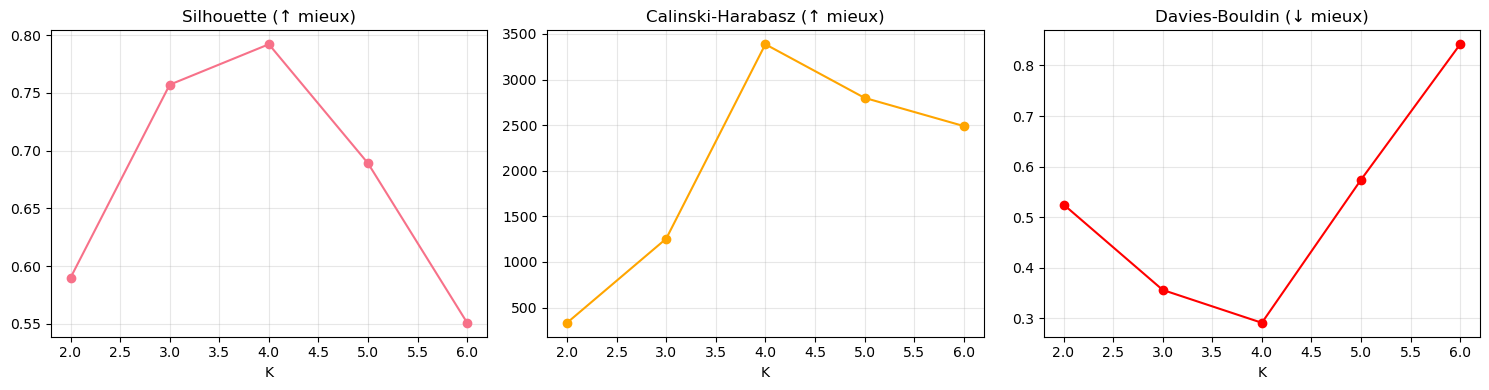


💡 Selon la Silhouette, le meilleur K serait: 4


In [14]:
# Démonstration des métriques
def demo_metriques():
    """Démonstration des métriques sur différents clusterings"""
    
    # Données de test
    X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)
    
    resultats = []
    
    # Test avec différents K
    for k in [2, 3, 4, 5, 6]:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        sil = silhouette_score(X, labels)
        from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
        cal = calinski_harabasz_score(X, labels)
        dav = davies_bouldin_score(X, labels)
        
        resultats.append({
            'K': k,
            'Silhouette': sil,
            'Calinski-Harabasz': cal,
            'Davies-Bouldin': dav
        })
    
    df_resultats = pd.DataFrame(resultats).round(3)
    
    print("📊 Évolution des métriques selon K:")
    display(df_resultats)
    
    # Graphiques
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].plot(df_resultats['K'], df_resultats['Silhouette'], 'o-')
    axes[0].set_title('Silhouette (↑ mieux)')
    axes[0].set_xlabel('K')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(df_resultats['K'], df_resultats['Calinski-Harabasz'], 'o-', color='orange')
    axes[1].set_title('Calinski-Harabasz (↑ mieux)')
    axes[1].set_xlabel('K')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(df_resultats['K'], df_resultats['Davies-Bouldin'], 'o-', color='red')
    axes[2].set_title('Davies-Bouldin (↓ mieux)')
    axes[2].set_xlabel('K')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Recommandation
    best_k_sil = df_resultats.loc[df_resultats['Silhouette'].idxmax(), 'K']
    print(f"\n💡 Selon la Silhouette, le meilleur K serait: {best_k_sil}")

demo_metriques()

## 4️⃣ Bonnes Pratiques & Pièges à Éviter

### ✅ Bonnes pratiques:
1. **Standardiser** les variables (échelles différentes)
2. **Explorer** les données avant clustering
3. **Tester** plusieurs algorithmes et paramètres
4. **Valider** avec plusieurs métriques
5. **Interpréter** les résultats avec l'expertise métier
6. **Itérer** et ajuster selon les besoins

### ❌ Pièges courants:
1. **Oublier la standardisation** → domination d'une variable
2. **Choisir K au hasard** → segments non pertinents
3. **Se fier à une seule métrique** → optimisation locale
4. **Ignorer les outliers** → biais dans les résultats
5. **Sur-segmenter** → trop de groupes ingérables
6. **Sous-segmenter** → groupes trop hétérogènes

In [11]:

# Quiz interactif de validation
questions_quiz = [
    {
        'question': "Quelle est la principale différence entre clustering et classification ?",
        'options': ['Le clustering utilise plus de données', 
                   'Le clustering ne connaît pas les classes à l\'avance',
                   'La classification est plus rapide',
                   'Il n\'y a pas de différence'],
        'bonne_reponse': 1
    },
    {
        'question': "Quel algorithme détecte automatiquement le bruit ?",
        'options': ['K-Means', 'CAH', 'DBSCAN', 'PCA'],
        'bonne_reponse': 2
    },
    {
        'question': "Pour la métrique Silhouette, que signifie une valeur proche de 1 ?",
        'options': ['Mauvaise séparation', 'Excellente séparation', 
                   'Trop de clusters', 'Pas assez de clusters'],
        'bonne_reponse': 1
    },
    {
        'question': "Pourquoi standardiser les variables avant clustering ?",
        'options': ['Pour accélérer les calculs', 
                   'Pour éviter qu\'une variable domine les autres',
                   'Pour réduire la mémoire utilisée',
                   'Ce n\'est pas nécessaire'],
        'bonne_reponse': 1
    }
]

@interact(
    question_num=IntSlider(min=1, max=len(questions_quiz), step=1, value=1, 
                          description='Question:')
)
def quiz_clustering(question_num):
    """Quiz interactif sur le clustering"""
    
    q = questions_quiz[question_num - 1]
    
    print(f"❓ Question {question_num}/{len(questions_quiz)}:")
    print(f"{q['question']}\n")
    
    for i, option in enumerate(q['options']):
        print(f"{i+1}. {option}")
    
    print(f"\n💡 Réponse: Option {q['bonne_reponse'] + 1}")
    
    if question_num == len(questions_quiz):
        print(f"\n🎉 Quiz terminé! Vous êtes prêt(e) pour l'exercice pratique.")

interactive(children=(IntSlider(value=1, description='Question:', max=4, min=1), Output()), _dom_classes=('wid…

## ✅ Récapitulatif - Prêt pour la Pratique!

🎯 **Points clés à retenir:**

**Clustering = Apprentissage non supervisé**
- Découverte de groupes sans étiquettes préalables
- 3 familles: Partitionnement, Hiérarchique, Densité

**Algorithmes principaux:**
- **K-Means**: Rapide, clusters sphériques, nécessite K
- **CAH**: Hiérarchie, dendrogramme, coûteux
- **DBSCAN**: Détecte bruit, formes variées, paramètres critiques

**Évaluation:**
- Métriques internes: Silhouette, Calinski-Harabasz, Davies-Bouldin
- Toujours combiner plusieurs métriques
- L'expertise métier est cruciale

**Workflow type:**
1. Explorer les données
2. Standardiser les variables
3. Tester plusieurs algorithmes/paramètres
4. Évaluer avec métriques multiples
5. Interpréter et valider métier
6. Itérer si nécessaire

**➡️ Vous êtes maintenant prêt(e) pour l'exercice pratique:**
- **Partie 1**: Exploration des données crédit
- **Partie 2**: Application des algorithmes
- **Partie 3**: Interprétation business et marketing

🚀 **Bonne chance pour la segmentation clients!**